<a href="https://colab.research.google.com/github/ItsSatria29/Airline-Delay-Cancellation/blob/main/airline_delay_and_cancellation_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download Data

In [ ]:
!kaggle datasets download -d yuanyuwendymu/airline-delay-and-cancellation-data-2009-2018
!unzip -q airline-delay-and-cancellation-data-2009-2018.zip -d /content/airline_dataset

Dataset URL: https://www.kaggle.com/datasets/yuanyuwendymu/airline-delay-and-cancellation-data-2009-2018
License(s): other
100% 1.95G/1.95G [00:19<00:00, 109MB/s]



## Spark Session Initialization

In [ ]:
# Spark Core
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType
from pyspark.sql.functions import col

# Spark ML - Feature Engineering
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# Spark ML - Modeling
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

# Spark ML - Evaluation
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# General
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Spark Session Section
spark = (
    SparkSession.builder
    .appName('AirlineDelay')
    .config('spark.sql.shuffle.partitions', '50')
    .config('spark.driver.memory', '8g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.parquet.compression.codec', 'snappy')
    .config('spark.sql.adaptive.enabled', 'true')   # AQE Spark 3.x
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'✅ Spark {spark.version} aktif | UI: {spark.sparkContext.uiWebUrl}')

✅ Spark 4.0.2 aktif | UI: http://cae52a3c39cf:4040


In [ ]:
# ─── Skema Eksplisit Airline Dataset (Kaggle) ───────────────────────────────────
# Mendefinisikan tipe setiap kolom secara eksplisit:
#   - Menghindari inferensi skema yang mahal (full scan)
#   - Memastikan tipe data benar sejak awal
AIRLINE_SCHEMA = StructType([
    StructField('FL_DATE',          StringType(),  True),  # cast ke Date nanti
    StructField('OP_CARRIER',       StringType(),  True),  # kode maskapai 2 huruf
    StructField('OP_CARRIER_FL_NUM',IntegerType(), True),  # nomor penerbangan
    StructField('ORIGIN',           StringType(),  True),  # kode bandara asal
    StructField('DEST',             StringType(),  True),  # kode bandara tujuan
    StructField('CRS_DEP_TIME',     IntegerType(), True),  # jadwal berangkat (HHMM)
    StructField('DEP_TIME',         FloatType(),   True),  # waktu aktual berangkat
    StructField('DEP_DELAY',        FloatType(),   True),  # keterlambatan berangkat (menit)
    StructField('TAXI_OUT',         FloatType(),   True),  # waktu taxi keluar
    StructField('WHEELS_OFF',       FloatType(),   True),  # waktu roda terangkat
    StructField('WHEELS_ON',        FloatType(),   True),  # waktu roda mendarat
    StructField('TAXI_IN',          FloatType(),   True),  # waktu taxi masuk
    StructField('CRS_ARR_TIME',     IntegerType(), True),  # jadwal tiba (HHMM)
    StructField('ARR_TIME',         FloatType(),   True),  # waktu aktual tiba
    StructField('ARR_DELAY',        FloatType(),   True),  # keterlambatan tiba (menit)
    StructField('CANCELLED',        FloatType(),   True),  # 1=dibatalkan
    StructField('CANCELLATION_CODE',StringType(),  True),  # A/B/C/D
    StructField('DIVERTED',         FloatType(),   True),  # 1=dialihkan
    StructField('CRS_ELAPSED_TIME', FloatType(),   True),  # estimasi durasi
    StructField('ACTUAL_ELAPSED_TIME', FloatType(),True),  # durasi aktual
    StructField('AIR_TIME',         FloatType(),   True),  # waktu di udara
    StructField('DISTANCE',         FloatType(),   True),  # jarak (mil)
    StructField('CARRIER_DELAY',    FloatType(),   True),  # delay akibat maskapai
    StructField('WEATHER_DELAY',    FloatType(),   True),  # delay akibat cuaca
    StructField('NAS_DELAY',        FloatType(),   True),  # delay NAS
    StructField('SECURITY_DELAY',   FloatType(),   True),  # delay keamanan
    StructField('LATE_AIRCRAFT_DELAY', FloatType(),True),  # delay pesawat terlambat tiba
    StructField('Unnamed: 27',      StringType(),  True),  # kolom artefak Kaggle
])

# Kolom yang kita butuhkan (optimasi .select())
NEEDED_COLS = [
    'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DEST',
    'DEP_DELAY', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE',
    'DIVERTED', 'DISTANCE', 'AIR_TIME',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

# Kolom numerik untuk analisis missing & imputasi
NUMERIC_COLS = [
    'DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'AIR_TIME',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

print(f'✅ Skema didefinisikan: {len(AIRLINE_SCHEMA.fields)} kolom')
print(f'✅ Kolom yang digunakan: {len(NEEDED_COLS)} kolom')

✅ Skema didefinisikan: 28 kolom
✅ Kolom yang digunakan: 16 kolom


## Data Loader

**Note:**
Data loader bisa dirun 1x saja, jika restart session bisa langsung ke Parquet.

In [ ]:
BASE_DIR = '/content/airline_dataset'
PARQUET_DIR = '/content/airline_parquet'

def load_year(spark, year, base_dir=BASE_DIR, schema=AIRLINE_SCHEMA,
              needed_cols=NEEDED_COLS, sample_frac=0.17):
    path = f'{base_dir}/{year}.csv'

    df = (
        spark.read
        .option('header', 'true')
        .option('enforceSchema', 'true')
        .option('nullValue', '')
        .option('nanValue', 'NA')
        .schema(schema)
        .csv(path)
    )

    df = (
        df.select(needed_cols)
        .sample(False, sample_frac, seed=42)   # sample ~17%
        .withColumn('YEAR', F.lit(year).cast(IntegerType()))
        .withColumn('FL_DATE', F.to_date('FL_DATE', 'yyyy-MM-dd'))
        .withColumn('MONTH', F.month('FL_DATE'))
        .withColumn('CANCELLED', F.col('CANCELLED').cast(IntegerType()))
        .withColumn('DIVERTED', F.col('DIVERTED').cast(IntegerType()))
    )

    return df

## Sampling 1m per year

**Note:**
Sampling juga sama bisa dirun 1x saja, jika restart session bisa langsung ke Parquet.

In [ ]:
# Sampling Parquet Data Operation
os.makedirs(PARQUET_DIR, exist_ok=True)

for yr in range(2009, 2019):
    print(f'📥 Processing {yr}...')

    df = load_year(spark, yr)

    # optional: cek jumlah sample bener nggak
    print(f'   Rows sampled: {df.count():,}')

    out_path = f'{PARQUET_DIR}/{yr}'
    df.write.mode('overwrite').parquet(out_path)

    print(f'   ✅ Saved -> {out_path}')

📥 Processing 2009...
   Rows sampled: 1,094,929
   ✅ Saved -> /content/airline_parquet/2009
📥 Processing 2010...
   Rows sampled: 1,098,542
   ✅ Saved -> /content/airline_parquet/2010
📥 Processing 2011...
   Rows sampled: 1,032,972
   ✅ Saved -> /content/airline_parquet/2011
📥 Processing 2012...
   Rows sampled: 1,037,915
   ✅ Saved -> /content/airline_parquet/2012
📥 Processing 2013...
   Rows sampled: 1,084,626
   ✅ Saved -> /content/airline_parquet/2013
📥 Processing 2014...
   Rows sampled: 990,807
   ✅ Saved -> /content/airline_parquet/2014
📥 Processing 2015...
   Rows sampled: 990,715
   ✅ Saved -> /content/airline_parquet/2015
📥 Processing 2016...
   Rows sampled: 956,651
   ✅ Saved -> /content/airline_parquet/2016
📥 Processing 2017...
   Rows sampled: 966,075
   ✅ Saved -> /content/airline_parquet/2017
📥 Processing 2018...
   Rows sampled: 1,228,608
   ✅ Saved -> /content/airline_parquet/2018


## Parquet

In [ ]:
# Definisi ulang Path Parquet
PARQUET_DIR = '/content/airline_parquet'

In [ ]:
# Variabel hasil Parquet
df_all = spark.read.parquet(f'{PARQUET_DIR}/*')

In [ ]:
print(df_all.count())
df_all.printSchema()
df_all.show(5)

10481840
root
 |-- FL_DATE: date (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- DEP_DELAY: float (nullable = true)
 |-- ARR_DELAY: float (nullable = true)
 |-- CANCELLED: integer (nullable = true)
 |-- CANCELLATION_CODE: string (nullable = true)
 |-- DIVERTED: integer (nullable = true)
 |-- DISTANCE: float (nullable = true)
 |-- AIR_TIME: float (nullable = true)
 |-- CARRIER_DELAY: float (nullable = true)
 |-- WEATHER_DELAY: float (nullable = true)
 |-- NAS_DELAY: float (nullable = true)
 |-- SECURITY_DELAY: float (nullable = true)
 |-- LATE_AIRCRAFT_DELAY: float (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)

+----------+----------+------+----+---------+---------+---------+-----------------+--------+--------+--------+-------------+-------------+---------+--------------+-------------------+----+-----+
|   FL_DATE|OP_CARRIER|ORIGIN|DEST|DEP_DELAY|ARR_

In [ ]:
df_all.groupBy("CANCELLED").count().show()

+---------+--------+
|CANCELLED|   count|
+---------+--------+
|        0|10315832|
|        1|  166008|
+---------+--------+



## Preprocessing

### Filtering

In [ ]:
feature_cols = [
    "DISTANCE",
    "MONTH",
    "DIVERTED",
    "OP_CARRIER",
    "ORIGIN",
    "DEST"
]

In [ ]:
label_col = "CANCELLED"

### Splitting

In [ ]:
train_data, test_data = df_all.randomSplit([0.8, 0.2], seed=42)

### Imbalance Handling

In [ ]:
minor = train_data.filter(col("CANCELLED") == 1)
major = train_data.filter(col("CANCELLED") == 0)

ratio = minor.count() / major.count()

major_sample = major.sample(False, ratio, seed=42)
train_balanced = major_sample.union(minor)

In [ ]:
train_balanced.groupBy("CANCELLED").count().show()

+---------+------+
|CANCELLED| count|
+---------+------+
|        0|133430|
|        1|133016|
+---------+------+



In [ ]:
train_balanced.printSchema()

root
 |-- FL_DATE: date (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- DEP_DELAY: float (nullable = true)
 |-- ARR_DELAY: float (nullable = true)
 |-- CANCELLED: integer (nullable = true)
 |-- CANCELLATION_CODE: string (nullable = true)
 |-- DIVERTED: integer (nullable = true)
 |-- DISTANCE: float (nullable = true)
 |-- AIR_TIME: float (nullable = true)
 |-- CARRIER_DELAY: float (nullable = true)
 |-- WEATHER_DELAY: float (nullable = true)
 |-- NAS_DELAY: float (nullable = true)
 |-- SECURITY_DELAY: float (nullable = true)
 |-- LATE_AIRCRAFT_DELAY: float (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)



### Missing Value Handling

In [ ]:
# Define fill values for numeric columns. Categorical columns will be handled by StringIndexer.
fill_values = {
    "DISTANCE": 0,
    "MONTH": 0,
    "DIVERTED": 0
}

train_model = train_balanced.select(feature_cols + [label_col]).fillna(fill_values)
test_model = test_data.select(feature_cols + [label_col]).fillna(fill_values)

In [ ]:
print(train_model.columns)

['DISTANCE', 'MONTH', 'DIVERTED', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CANCELLED']


In [ ]:
# misval checker
for c in feature_cols:
    print(c, train_model.filter(col(c).isNull()).count())

DISTANCE 0
MONTH 0
DIVERTED 0
OP_CARRIER 0
ORIGIN 0
DEST 0


In [ ]:
# feature checker
print(feature_cols)
print(train_model.columns)

['DISTANCE', 'MONTH', 'DIVERTED', 'OP_CARRIER', 'ORIGIN', 'DEST']
['DISTANCE', 'MONTH', 'DIVERTED', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CANCELLED']


## Tranformation

### Feature Engineering

In [ ]:
# categorical features
cat_cols = ["OP_CARRIER", "ORIGIN", "DEST"]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in cat_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_vec"
    )
    for c in cat_cols
]

num_cols = ["DISTANCE", "MONTH", "DIVERTED"]

assembler_num = VectorAssembler(
    inputCols=num_cols,
    outputCol="num_features"
)

scaler = StandardScaler(
    inputCol="num_features",
    outputCol="scaled_num_features",
    withMean=True,
    withStd=True
)

# final combine
final_features = ["scaled_num_features"] + [f"{c}_vec" for c in cat_cols]

assembler_final = VectorAssembler(
    inputCols=final_features,
    outputCol="features"
)

pipeline = Pipeline(stages=
    indexers +
    encoders +
    [assembler_num, scaler, assembler_final]
)

# fit on train only
pipeline_model = pipeline.fit(train_model)

# transform both
train_final = pipeline_model.transform(train_model).select("features", "CANCELLED")
test_final = pipeline_model.transform(test_model).select("features", "CANCELLED")

In [ ]:
print(train_model.columns)

['DISTANCE', 'MONTH', 'DIVERTED', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CANCELLED']


In [ ]:
# vector checker
train_final.show(5, truncate=False)
test_final.show(5, truncate=False)

+--------------------------------------------------------------------------------------------------+---------+
|features                                                                                          |CANCELLED|
+--------------------------------------------------------------------------------------------------+---------+
|(761,[0,1,2,13,39,539],[-1.184691750420587,-1.4364211374809726,-0.03440382492813851,1.0,1.0,1.0]) |0        |
|(761,[0,1,2,4,28,587],[0.014500720895027802,-1.4364211374809726,-0.03440382492813851,1.0,1.0,1.0])|0        |
|(761,[0,1,2,4,31,406],[3.1840531111945816,-1.4364211374809726,-0.03440382492813851,1.0,1.0,1.0])  |0        |
|(761,[0,1,2,4,42,396],[0.491288089008465,-1.4364211374809726,-0.03440382492813851,1.0,1.0,1.0])   |0        |
|(761,[0,1,2,4,26,396],[0.1625937670514742,-1.4364211374809726,-0.03440382492813851,1.0,1.0,1.0])  |0        |
+--------------------------------------------------------------------------------------------------+---------+
o

## Modeling

### Logistic Regression

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="CANCELLED"
)

lr_model = lr.fit(train_final)

### Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="CANCELLED",
    numTrees=80,
    maxDepth=12,
    maxBins=800,
    seed=42

)

rf_model = rf.fit(train_final)

## Evaluation

### Predict

In [ ]:
pred_lr = lr_model.transform(test_final)
pred_rf = rf_model.transform(test_final)

pred_lr.cache()
pred_rf.cache()

DataFrame[features: vector, CANCELLED: int, rawPrediction: vector, probability: vector, prediction: double]

### Model Performance Metrics

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="CANCELLED",
    metricName="areaUnderROC"
)

auc_lr = evaluator.evaluate(pred_lr)
auc_rf = evaluator.evaluate(pred_rf)

print("LR AUC:", auc_lr)
print("RF AUC:", auc_rf)

LR AUC: 0.711627096684991
RF AUC: 0.7057226640791747


In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Evaluator setup
binary_eval = BinaryClassificationEvaluator(
    labelCol="CANCELLED", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
multi_eval_acc = MulticlassClassificationEvaluator(
    labelCol="CANCELLED", predictionCol="prediction", metricName="accuracy"
)
multi_eval_prec = MulticlassClassificationEvaluator(
    labelCol="CANCELLED", predictionCol="prediction", metricName="weightedPrecision"
)
multi_eval_rec = MulticlassClassificationEvaluator(
    labelCol="CANCELLED", predictionCol="prediction", metricName="weightedRecall"
)
multi_eval_f1 = MulticlassClassificationEvaluator(
    labelCol="CANCELLED", predictionCol="prediction", metricName="f1"
)

predictions = {
    "Logistic Regression": pred_lr,
    "Random Forest": pred_rf
}

for name, pred in predictions.items():
    print(f"\n=== {name} ===")
    auc = binary_eval.evaluate(pred)
    acc = multi_eval_acc.evaluate(pred)
    precision = multi_eval_prec.evaluate(pred)
    recall = multi_eval_rec.evaluate(pred)
    f1 = multi_eval_f1.evaluate(pred)

    print("AUC:", auc)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)



=== Logistic Regression ===
AUC: 0.7116243419873157
Accuracy: 0.6544961387115809
Precision: 0.9766008358597633
Recall: 0.654496138711581
F1: 0.7770022785222761

=== Random Forest ===
AUC: 0.705720311991329
Accuracy: 0.6400284116793182
Precision: 0.9764218400777407
Recall: 0.6400284116793182
F1: 0.7663115409788082


### Prediction Distribution

In [ ]:
pred_rf.groupBy("CANCELLED", "prediction").count().show()

+---------+----------+-------+
|CANCELLED|prediction|  count|
+---------+----------+-------+
|        0|       0.0|1319922|
|        1|       0.0|  11209|
|        1|       1.0|  21783|
|        0|       1.0| 743407|
+---------+----------+-------+



## Insight

### Feature Importance

In [ ]:
import pandas as pd

attrs = train_final.schema["features"].metadata["ml_attr"]["attrs"]

feature_names = []

for attr_type in attrs:
    feature_names += [x["name"] for x in attrs[attr_type]]

importance = rf_model.featureImportances.toArray()

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print(fi_df.head(20))

               feature  importance
1    OP_CARRIER_vec_AA    0.148262
0    OP_CARRIER_vec_WN    0.124256
8    OP_CARRIER_vec_US    0.085293
7    OP_CARRIER_vec_B6    0.064415
6    OP_CARRIER_vec_UA    0.055088
3    OP_CARRIER_vec_EV    0.044312
399       DEST_vec_IAH    0.036332
30      ORIGIN_vec_SFO    0.030558
394       DEST_vec_DEN    0.026598
47      ORIGIN_vec_SAN    0.023018
26      ORIGIN_vec_DEN    0.022688
22   OP_CARRIER_vec_G4    0.020623
15   OP_CARRIER_vec_F9    0.018279
37      ORIGIN_vec_DCA    0.015802
32      ORIGIN_vec_BOS    0.013548
409       DEST_vec_BWI    0.013072
16   OP_CARRIER_vec_NK    0.013005
400       DEST_vec_BOS    0.011808
48      ORIGIN_vec_MIA    0.011606
27      ORIGIN_vec_LGA    0.011246


In [ ]:
fi_df[fi_df["feature"].str.contains("scaled_num_features")]

,feature,importance
759,scaled_num_features_1,0.000001
758,scaled_num_features_0,0.000000
760,scaled_num_features_2,0.000000


In [ ]:
# import pandas as pd

# importance = rf_model.featureImportances.toArray()

# fi_df = pd.DataFrame({
#     "feature": feature_cols,
#     "importance": importance
# })

# fi_df = fi_df.sort_values("importance", ascending=False)

# print(fi_df)

ValueError: All arrays must be of the same length

### Visualization

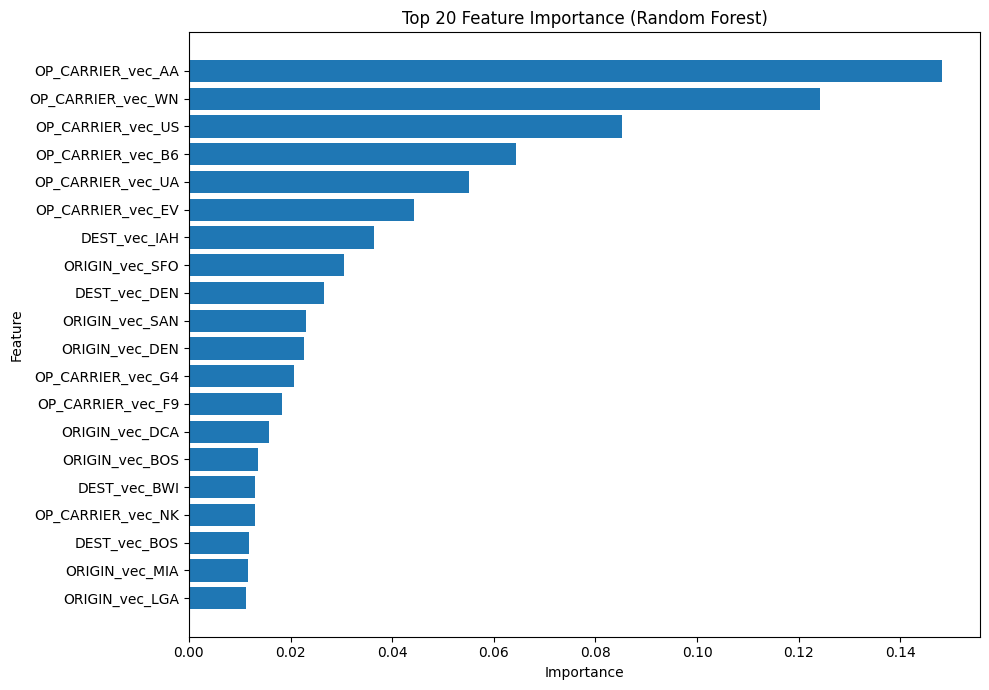

In [ ]:
import matplotlib.pyplot as plt

top_n = 20
top_features = fi_df.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

In [ ]:
fi_df["group"] = fi_df["feature"].apply(lambda x:
    "OP_CARRIER" if "OP_CARRIER" in x else
    "ORIGIN" if "ORIGIN" in x else
    "DEST" if "DEST" in x else
    "NUMERIC"
)

grouped = fi_df.groupby("group")["importance"].sum().reset_index()
print(grouped.sort_values("importance", ascending=False))

        group  importance
2  OP_CARRIER    0.614282
3      ORIGIN    0.205300
0        DEST    0.180417
1     NUMERIC    0.000001


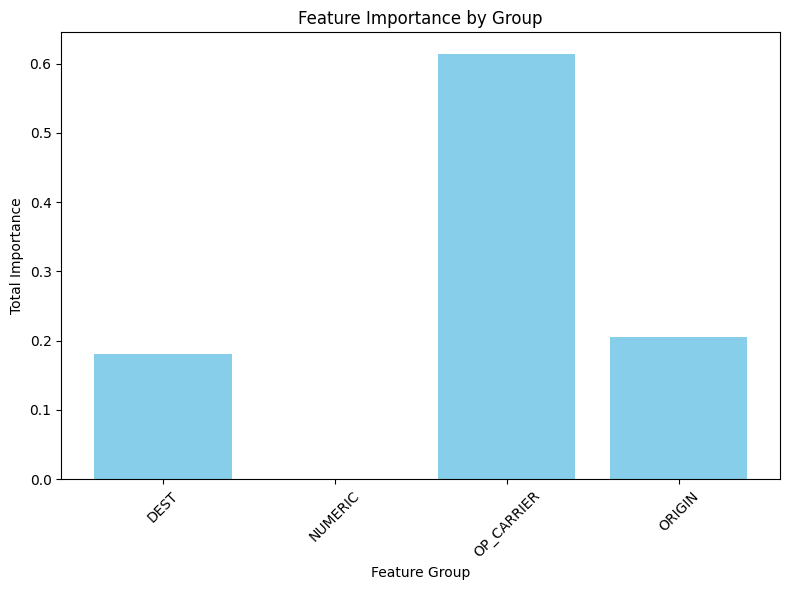

In [ ]:
import matplotlib.pyplot as plt

# Bar chart feature importance
plt.figure(figsize=(8,6))
plt.bar(grouped["group"], grouped["importance"], color="skyblue")

plt.title("Feature Importance by Group")
plt.xlabel("Feature Group")
plt.ylabel("Total Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Model Inference

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id
from pyspark.ml.functions import vector_to_array

# Ambil 5 sampel random dari df_all yang tidak ada missing value + sample dikunci
sample_data = df_all.select(feature_cols + [label_col]) \
    .dropna() \
    .sample(False, 0.0001, seed=99) \
    .limit(5) \
    .withColumn("id", monotonically_increasing_id())

# Transform pakai pipeline yang sudah dilatih
sample_transformed = pipeline_model.transform(sample_data).select("id", "features", "CANCELLED")

# Prediksi pakai LR model
pred_sample = lr_model.transform(sample_transformed)

# Tampilkan hasil: aktual vs prediksi join dengan data asli
result = sample_data.join(pred_sample.select("id", "prediction", "probability"), on="id")
result.select(feature_cols + [label_col, "prediction", "probability"]).show(truncate=False)

# Akurasi
correct = result.filter(col("CANCELLED") == col("prediction")).count()
print(f"Akurasi 5 sampel: {correct}/5")

+--------+-----+--------+----------+------+----+---------+----------+----------------------------------------+
|DISTANCE|MONTH|DIVERTED|OP_CARRIER|ORIGIN|DEST|CANCELLED|prediction|probability                             |
+--------+-----+--------+----------+------+----+---------+----------+----------------------------------------+
|2345.0  |1    |0       |AS        |LAX   |ANC |0        |0.0       |[0.7981884078300311,0.2018115921699689] |
|317.0   |1    |0       |WN        |MKE   |STL |0        |0.0       |[0.5548242288807563,0.44517577111924367]|
|163.0   |1    |0       |HA        |HNL   |KOA |0        |0.0       |[0.8566752479392387,0.14332475206076134]|
|907.0   |1    |0       |DL        |MSP   |ATL |0        |0.0       |[0.662788865371263,0.337211134628737]   |
|496.0   |1    |0       |B6        |BOS   |PIT |0        |1.0       |[0.4391333316099853,0.5608666683900148] |
+--------+-----+--------+----------+------+----+---------+----------+----------------------------------------+



## Alternate Universe (Modeling With Imbalance Data)

In [ ]:
train_modelau = train_data.select(feature_cols + [label_col]).fillna({
  # "DEP_DELAY": 0,
    "DISTANCE": 0,
    "DIVERTED": 0,
    "MONTH": 0,
})

In [ ]:
for c in feature_cols:
    print(c, train_modelau.filter(col(c).isNull()).count())

DISTANCE 0
MONTH 0
DIVERTED 0
OP_CARRIER 0
ORIGIN 0
DEST 0


In [ ]:
train_modelau.groupBy("CANCELLED").count().show()

+---------+-------+
|CANCELLED|  count|
+---------+-------+
|        0|8252503|
|        1| 133016|
+---------+-------+



In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_finalau = assembler.transform(train_modelau).select("features", "CANCELLED")

IllegalArgumentException: Data type string of column OP_CARRIER is not supported.
Data type string of column ORIGIN is not supported.
Data type string of column DEST is not supported.

In [ ]:
from pyspark.ml.classification import LogisticRegression

lrau = LogisticRegression(
    featuresCol="features",
    labelCol="CANCELLED"
)

lr_modelau = lrau.fit(train_finalau)

NameError: name 'train_finalau' is not defined

In [ ]:
pred_lrau = lr_modelau.transform(test_final)

NameError: name 'lr_modelau' is not defined

### Evaluation

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# AUC
aucau = BinaryClassificationEvaluator(
    labelCol="CANCELLED",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(pred_lrau)

# Accuracy
accau = MulticlassClassificationEvaluator(
    labelCol="CANCELLED",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(pred_lrau)

# Precision
precisionau = MulticlassClassificationEvaluator(
    labelCol="CANCELLED",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(pred_lrau)

# Recall
recallau = MulticlassClassificationEvaluator(
    labelCol="CANCELLED",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(pred_lrau)

# F1
f1au = MulticlassClassificationEvaluator(
    labelCol="CANCELLED",
    predictionCol="prediction",
    metricName="f1"
).evaluate(pred_lrau)

print("AUC:", aucau)
print("Accuracy:", accau)
print("Precision:", precisionau)
print("Recall:", recallau)
print("F1:", f1au)

NameError: name 'pred_lrau' is not defined

# **9. Faktor apa yang paling mempengaruhi delay/cancellation berdasarkan hasil model**

=== Feature Importance per Grup (Random Forest) ===
                         group  importance
         OP_CARRIER (Maskapai)    0.614282
         ORIGIN (Bandara Asal)    0.205300
         DEST (Bandara Tujuan)    0.180417
NUMERIC (Jarak/Bulan/Diverted)    0.000001

 Faktor paling berpengaruh: OP_CARRIER (Maskapai) (total importance: 0.6143)
  OP_CARRIER (Maskapai) adalah kelompok variabel yang paling menentukan apakah penerbangan akan dibatalkan atau tidak.


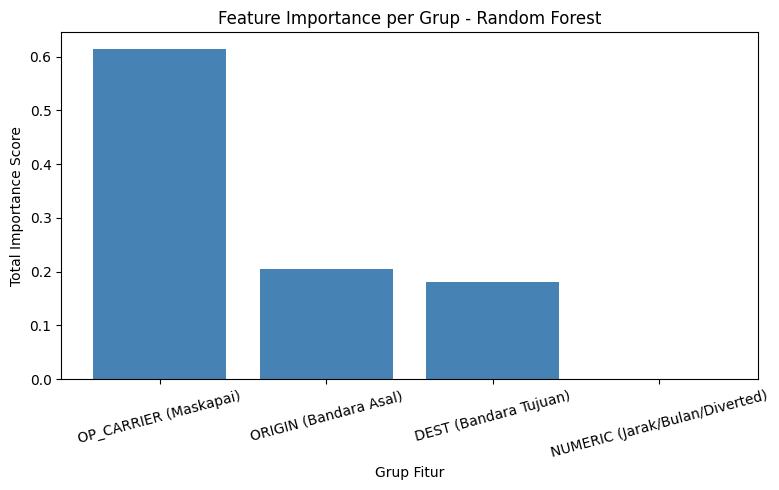

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ambil nama fitur dari metadata vector
attrs = train_final.schema["features"].metadata["ml_attr"]["attrs"]
feature_names = []
for attr_type in attrs:
    feature_names += [x["name"] for x in attrs[attr_type]]

importance = rf_model.featureImportances.toArray()

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Kelompokkan per grup fitur asli
def get_group(name):
    if "OP_CARRIER" in name: return "OP_CARRIER (Maskapai)"
    elif "ORIGIN" in name:   return "ORIGIN (Bandara Asal)"
    elif "DEST" in name:     return "DEST (Bandara Tujuan)"
    else:                    return "NUMERIC (Jarak/Bulan/Diverted)"

fi_df["group"] = fi_df["feature"].apply(get_group)
grouped = fi_df.groupby("group")["importance"].sum().reset_index()
grouped = grouped.sort_values("importance", ascending=False)

print("=== Feature Importance per Grup (Random Forest) ===")
print(grouped.to_string(index=False))

top = grouped.iloc[0]
print(f"\n Faktor paling berpengaruh: {top['group']} (total importance: {top['importance']:.4f})")
print(f"  {top['group']} adalah kelompok variabel yang paling menentukan apakah penerbangan akan dibatalkan atau tidak.")

# Visualisasi
plt.figure(figsize=(8, 5))
plt.bar(grouped["group"], grouped["importance"], color="steelblue")
plt.title("Feature Importance per Grup - Random Forest")
plt.xlabel("Grup Fitur")
plt.ylabel("Total Importance Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# **10. Rekomendasi yang dapat diberikan kepada maskapai atau bandara berdasarkan hasil analisis dan prediksi?**

 Maskapai dengan cancel rate tertinggi: OH (3.58%)
  Rekomendasi: Maskapai OH perlu evaluasi operasional seperti penjadwalan ulang atau penambahan armada cadangan.



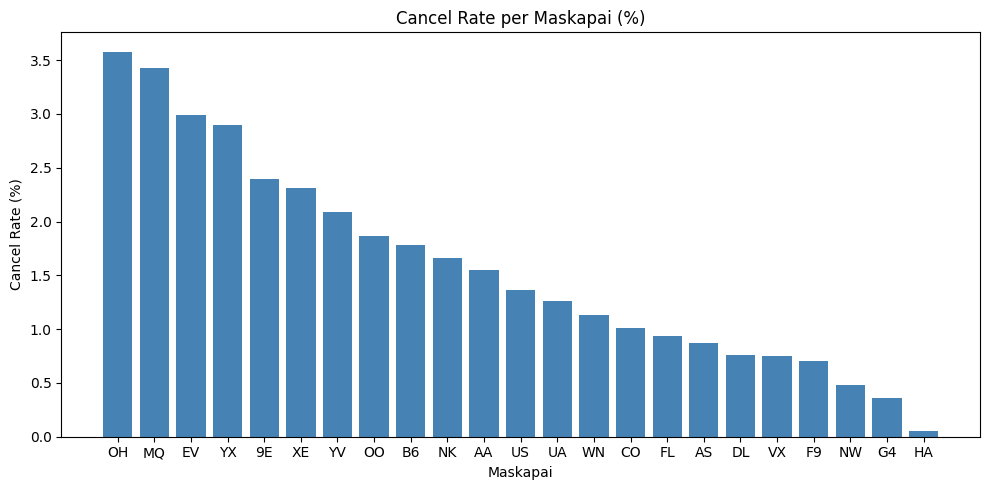

Bandara asal dengan cancel rate tertinggi: HVN (36.36%)
Rekomendasi: Bandara HVN perlu koordinasi lebih ketat dengan ATC dan penambahan buffer waktu antar penerbangan.



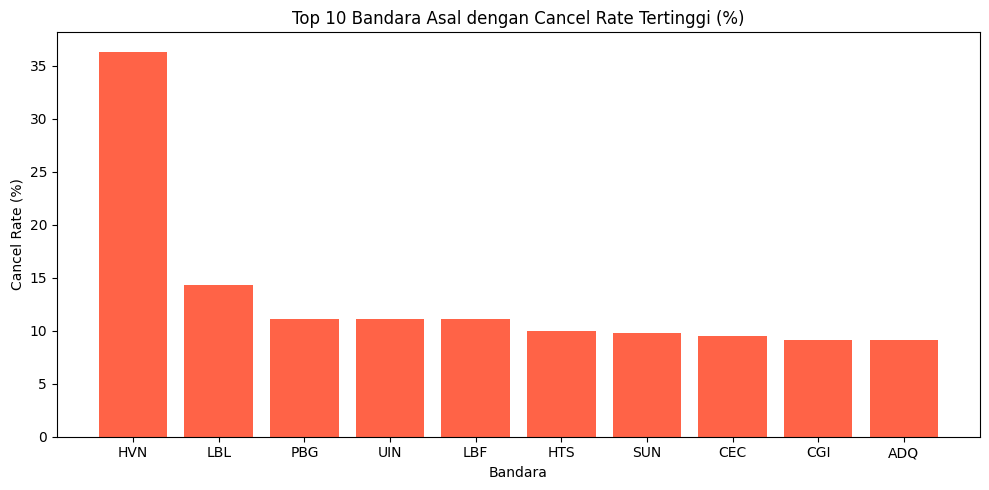

Bulan dengan cancel rate tertinggi: Bulan 2 (3.05%)
Rekomendasi: Maskapai sebaiknya menambah buffer waktu dan armada cadangan pada bulan 2 untuk mengantisipasi lonjakan pembatalan.



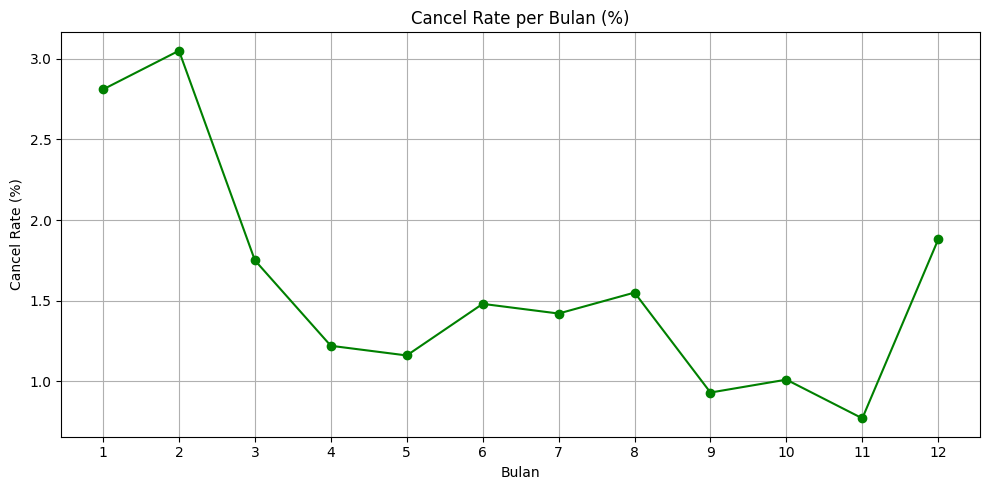

In [ ]:
import matplotlib.pyplot as plt

df_pd = df_all.select("OP_CARRIER", "ORIGIN", "DEST", "MONTH", "CANCELLED") \
              .dropna() \
              .sample(False, 0.05, seed=42) \
              .toPandas()

# 1. Cancel rate per maskapai
carrier_cancel = df_pd.groupby("OP_CARRIER")["CANCELLED"].mean().sort_values(ascending=False).reset_index()
carrier_cancel.columns = ["Maskapai", "Cancel Rate"]
carrier_cancel["Cancel Rate"] = (carrier_cancel["Cancel Rate"] * 100).round(2)

top_carrier = carrier_cancel.iloc[0]
print(f" Maskapai dengan cancel rate tertinggi: {top_carrier['Maskapai']} ({top_carrier['Cancel Rate']}%)")
print(f"  Rekomendasi: Maskapai {top_carrier['Maskapai']} perlu evaluasi operasional seperti penjadwalan ulang atau penambahan armada cadangan.\n")

plt.figure(figsize=(10, 5))
plt.bar(carrier_cancel["Maskapai"], carrier_cancel["Cancel Rate"], color="steelblue")
plt.title("Cancel Rate per Maskapai (%)")
plt.xlabel("Maskapai")
plt.ylabel("Cancel Rate (%)")
plt.tight_layout()
plt.show()

# 2. Top 10 bandara asal dengan cancel rate tertinggi
origin_cancel = df_pd.groupby("ORIGIN")["CANCELLED"].mean().sort_values(ascending=False).head(10).reset_index()
origin_cancel.columns = ["Bandara Asal", "Cancel Rate"]
origin_cancel["Cancel Rate"] = (origin_cancel["Cancel Rate"] * 100).round(2)

top_origin = origin_cancel.iloc[0]
print(f"Bandara asal dengan cancel rate tertinggi: {top_origin['Bandara Asal']} ({top_origin['Cancel Rate']}%)")
print(f"Rekomendasi: Bandara {top_origin['Bandara Asal']} perlu koordinasi lebih ketat dengan ATC dan penambahan buffer waktu antar penerbangan.\n")

plt.figure(figsize=(10, 5))
plt.bar(origin_cancel["Bandara Asal"], origin_cancel["Cancel Rate"], color="tomato")
plt.title("Top 10 Bandara Asal dengan Cancel Rate Tertinggi (%)")
plt.xlabel("Bandara")
plt.ylabel("Cancel Rate (%)")
plt.tight_layout()
plt.show()

# 3. Cancel rate per bulan
month_cancel = df_pd.groupby("MONTH")["CANCELLED"].mean().reset_index()
month_cancel.columns = ["Bulan", "Cancel Rate"]
month_cancel["Cancel Rate"] = (month_cancel["Cancel Rate"] * 100).round(2)

top_month = month_cancel.sort_values("Cancel Rate", ascending=False).iloc[0]
print(f"Bulan dengan cancel rate tertinggi: Bulan {int(top_month['Bulan'])} ({top_month['Cancel Rate']}%)")
print(f"Rekomendasi: Maskapai sebaiknya menambah buffer waktu dan armada cadangan pada bulan {int(top_month['Bulan'])} untuk mengantisipasi lonjakan pembatalan.\n")

plt.figure(figsize=(10, 5))
plt.plot(month_cancel["Bulan"], month_cancel["Cancel Rate"], marker="o", color="green")
plt.title("Cancel Rate per Bulan (%)")
plt.xlabel("Bulan")
plt.ylabel("Cancel Rate (%)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()